# Семинар №3. Оптимизация

**План**
1. Попробуем написать логистическую регрессию руками

## Импорты

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris, make_classification
from sklearn.metrics import classification_report

## Logistic regression

Из тетрадки по логистической регрессии:
$y(x_1, ..., x_n) = \sigma (w_0 + w_1 * x_1 + ... + w_n * x_n) = \sigma (\langle w, x \rangle + w_0)$,

где
- $w$ - вектор весов $w_1, ..., w_n$
- $x$ - вектор признаков $x_1, ..., x_n$
- $\langle w, x \rangle$ - скалярное произведение
- $\sigma(x) = \frac{1}{1 + e^{-x}}$ - логистическая функция (или сигмоида, хотя сигмоида на самом деле - это класс функций)

_Напомню, что по определению скалярного произведения $\langle a, b \rangle = \displaystyle\sum_{i=1}^n a_i * b_i$_

Для простоты будем считать, что у нас:

$y(x_1, ..., x_n) = \sigma (\langle w, x \rangle)$


Сделаем случайные данные для классификации, сначала для двух признаков, чтобы было можно рисовать результат

In [2]:
n_features = 2

X, y = make_classification(n_samples=100, n_features=n_features, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           shuffle=True, random_state=42)
X.shape, y.shape

((100, 2), (100,))

Можно ли с нашими данными работать без свободного коэффициента регрессии?

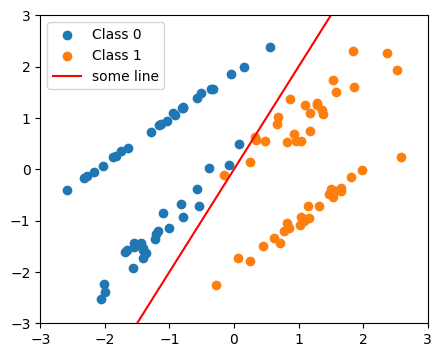

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.set_xlim(-3, 3), ax.set_ylim(-3, 3)

ax.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1')
ax.plot([-3, 3], [-6, 6], label='some line', color='red')
ax.legend();

В нашей регресси весов должно быть столько же, сколько и признаков (так как свободный коэффициент мы решили не брать). Сделаем вектор с ними, пока случайный

In [4]:
W = np.random.rand(n_features)
W

array([0.65086189, 0.77199473])

Теперь поймем, как из этого посчитать предсказание логистической регрессии

$y(x_1, ..., x_n) = \sigma (\langle w, x \rangle)$

In [8]:
pred = 1 / (1 + np.exp(- np.dot(W, X.T)))
pred

array([0.90098062, 0.57451131, 0.07577141, 0.16931085, 0.66494764,
       0.59817697, 0.1281514 , 0.67626878, 0.14608899, 0.22783859,
       0.86708933, 0.60538659, 0.15479948, 0.75745271, 0.68960718,
       0.10652982, 0.45742378, 0.25802368, 0.6636445 , 0.18990971,
       0.34567202, 0.45311072, 0.10885019, 0.11930652, 0.43144915,
       0.505562  , 0.35025844, 0.67845732, 0.85874953, 0.5673424 ,
       0.80190441, 0.03599348, 0.21908034, 0.09175928, 0.8615895 ,
       0.74208118, 0.26054359, 0.55864572, 0.20117738, 0.44084949,
       0.66710712, 0.75010342, 0.69255822, 0.77483605, 0.48698833,
       0.09613532, 0.41815174, 0.21490449, 0.64301955, 0.39485956,
       0.32073679, 0.75347508, 0.83341631, 0.84322761, 0.55512621,
       0.10755641, 0.73023687, 0.2962292 , 0.17719156, 0.48771174,
       0.28692513, 0.48276343, 0.72118981, 0.66027523, 0.43214847,
       0.54957398, 0.10414366, 0.16097043, 0.72656222, 0.79120153,
       0.89850724, 0.08719793, 0.51499904, 0.95150524, 0.91231

In [9]:
def predict(W, X, eps=1e-15, threshold=None):
    pred = 1 / (1 + np.exp(- np.dot(W, X.T)))

    if threshold is not None:
        pred = (pred > threshold).astype(int)

    return pred

Теперь нам надо выбрать какую-то функцию потерь. Пусть это будет кросс-энтропия

$\mathrm{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{y_i}) + (1 - y_i) \cdot \log(1 - \hat{y_i}) \right]$

In [10]:
eps = 1e-15

# чтобы не получить логарифм от нуля
clip_pred = np.clip(pred, eps, 1 - eps)

# сама кросс-энтропия
loss = - (y * np.log(clip_pred) + (1 - y) * np.log(1 - clip_pred))

np.mean(loss)

np.float64(0.506003419166349)

In [11]:
def compute_loss(pred, y, eps=1e-15):
    loss = - (y * np.log(pred) + (1 - y) * np.log(1 - pred))
    return np.mean(loss)

А теперь нам надо понять, как запустить градиентный спуск для этого результата.

- Что у нас будет переменными, а что константами?
- Какая функуция в итоге? Как записать то, что мы делали с начала и до конца?

In [12]:
# Тут надо написать производную

grad = np.dot((clip_pred - y), X) / y.shape[0]
grad

array([-0.27634508,  0.21547456])

In [13]:
alpha = 0.1
new_W = W - alpha * grad

new_W

array([0.6784964 , 0.75044727])

In [14]:
def count_grad(pred, X, y):
    grad = np.dot((pred - y), X) / y.shape[0]
    return grad

Соберем все в одну функцию

In [19]:
def regression_step(W, X, y, eps=1e-15, alpha=0.1):
    pred = predict(W, X, eps=1e-15, threshold=None)
    clip_pred = np.clip(pred, eps, 1 - eps)
    loss = compute_loss(clip_pred, y, eps=eps)
    grad = count_grad(clip_pred, X, y)
    new_W = W - alpha * grad
    return loss, new_W, np.linalg.norm(grad)

И теперь попробуем написать цикл обучения:
1. Делаем шаг (функция выше)
2. Проверяем, что норма градиента выше эпсилон (зачем?) и что лосс падает
3. Если в пункте 2 все ок, то повторяем 1-2

In [20]:
def train_logreg(X, y, n_steps=100, eps = 1e-15, alpha=0.1):
    W = np.random.rand(X.shape[1])
    losses, norms, weights = [], [], []

    for i in range(n_steps):
        weights.append(W)

        loss, W, norm = regression_step(W, X, y, eps=eps, alpha=alpha)
        losses.append(loss), norms.append(norm)

        if (norm < eps) or (loss > losses[max(0, i - 1)]):
            print('Early stop')
            break

    return W, losses, norms, weights

In [21]:
n_steps = 100
eps = 1e-15

W, losses, norms, w_hist = train_logreg(X, y, n_steps=100, eps = 1e-15)

Посмотрим, как меняются лоссы и нормы градиента в процессе обучения

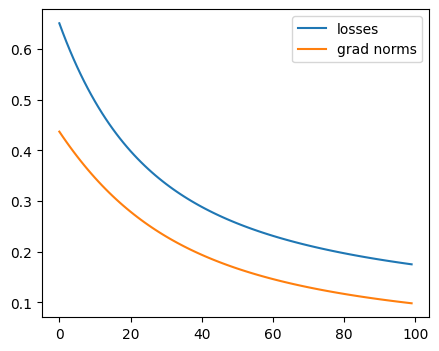

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(np.arange(n_steps), losses, label='losses')
ax.plot(np.arange(n_steps), norms, label='grad norms')
ax.legend();

Посмотрим, как мы учимся

In [23]:
w_hist = np.array(w_hist)

In [24]:
# Для красивой сетки значений

eps = 0.1
w1_vals = np.linspace(w_hist[:, 0].min() - eps, w_hist[:, 0].max() + eps, 20)
w2_vals = np.linspace(w_hist[:, 1].min() - eps, w_hist[:, 1].max() + eps, 20)
w1_grid, w2_grid = np.meshgrid(w1_vals, w2_vals)
loss_grid = np.zeros_like(w1_grid)

for i in range(w1_grid.shape[0]):
    for j in range(w1_grid.shape[1]):
        w = np.array([w1_grid[i, j], w2_grid[i, j]])
        pred = predict(w, X, eps=1e-15, threshold=None)
        loss_grid[i, j] = np.mean(compute_loss(pred, y))

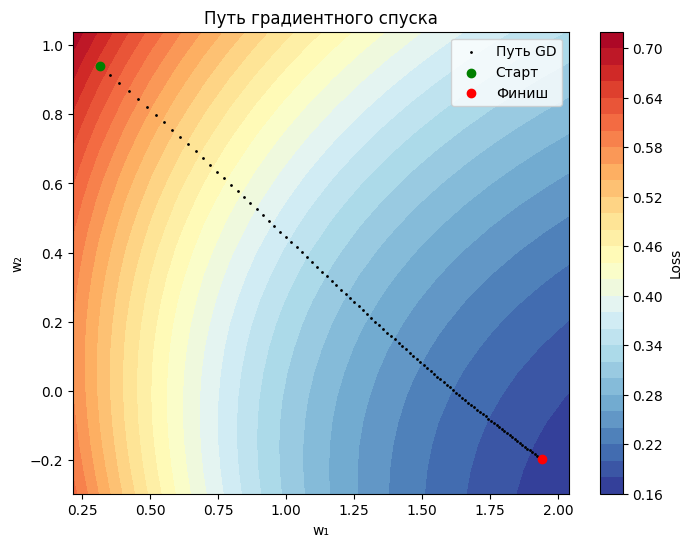

In [25]:
plt.figure(figsize=(8, 6))
contours = plt.contourf(w1_grid, w2_grid, loss_grid, levels=30, cmap='RdYlBu_r')
plt.colorbar(contours, label='Loss')

plt.scatter(w_hist[:, 0], w_hist[:, 1], label='Путь GD', color='black', s=1)
plt.scatter(w_hist[0, 0], w_hist[0, 1], c='green', label='Старт')
plt.scatter(w_hist[-1, 0], w_hist[-1, 1], c='red', label='Финиш')

plt.xlabel('w₁'), plt.ylabel('w₂')
plt.title('Путь градиентного спуска')
plt.legend()
plt.show()

In [26]:
W

array([ 1.94795013, -0.20127367])

И посмотрим на качество

In [27]:
preds = predict(W, X, eps=1e-15, threshold=0.5)
print(classification_report(y, preds))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        50
           1       0.96      0.96      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



Попробуем на настоящем датасете

In [28]:
data = load_iris()
X, y, names = data['data'], data['target'], data['target_names']

Мы умеем решать только бинарную классификацию, так что один класс уберем

In [29]:
idx = (data['target'] != 2)
X, y, names = X[idx], y[idx], names[:-1]

In [30]:
n_steps = 100
eps = 1e-15

W, losses, norms, _ = train_logreg(X, y, n_steps=n_steps, eps=eps)

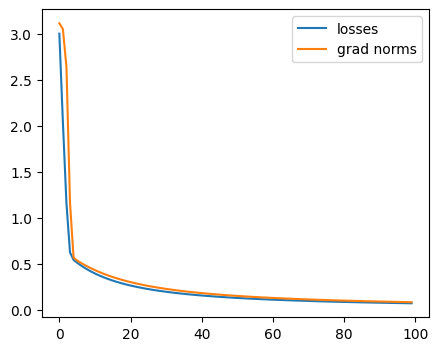

In [31]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(np.arange(len(losses)), losses, label='losses')
ax.plot(np.arange(len(norms)), norms, label='grad norms')
ax.legend();

In [32]:
preds = predict(W, X, eps=1e-15, threshold=0.5)
print(classification_report(y, preds, target_names=names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

